In [2]:
import os
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.stats import wasserstein_distance
from scipy.stats import chi2 as chi2_stat
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch

# Force CPU (Prevents PyTorch pin_memory CUDA crashes)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Adjust to your setup
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

In [3]:
# ==============================================================================
# 1. PLOTTING FUNCTION (SR Extrapolation)
# ==============================================================================
def plot_sr_extrapolation(mode_label: str, df_mc: pl.DataFrame, df_gen: pl.DataFrame, df_data: pl.DataFrame, feature: str, force_log: bool = False):
    plt.rcParams.update({
        'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12, 'lines.linewidth': 1.5, 'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.top': True, 'ytick.right': True, 'axes.formatter.use_mathtext': True, 'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]', 'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]', 'ljet1_tau21': r'Leading jet $\tau_{21}$', 'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$', 'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    log_variables = ['ht', 'met_recalc_pt', 'met', 'mjj']
    use_log = force_log or any(log_var in feature.lower() for log_var in log_variables)
    
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    mc_arr = df_mc.get_column(feature).drop_nulls().to_numpy()
    gen_arr = df_gen.get_column(feature).drop_nulls().to_numpy() if df_gen is not None and feature in df_gen.columns else np.array([])
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid observed data.")
        return
        
    raw_weights = df_mc.get_column("final_weight").to_numpy()
    extrapolated_weights = df_mc.get_column("extrapolated_SR_weight").to_numpy()
    gen_weights = df_gen.get_column("weight").to_numpy() if df_gen is not None else np.array([])
    
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    arrays_to_concat = [data_arr, mc_arr]
    if len(gen_arr) > 0: arrays_to_concat.append(gen_arr)
    combined_arr = np.concatenate(arrays_to_concat)
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- MAIN PANEL ---
    counts_mc_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights)
    sumw2_raw, _ = np.histogram(mc_arr, bins=bins, weights=raw_weights**2)
    ax_main.hist(mc_arr, bins=bins, weights=raw_weights, histtype='step', color='#e31a1c', linewidth=2, linestyle='--', label='Nominal MC')
                 
    mc_err = np.sqrt(sumw2_raw)
    ax_main.bar(bin_centers, 2 * mc_err, bottom=counts_mc_raw - mc_err, width=bin_widths, color='none', edgecolor='gray', hatch='////', linewidth=0, alpha=0.5, zorder=5, label='Stat. Unc.')
    
    counts_mc_extrap, _ = np.histogram(mc_arr, bins=bins, weights=extrapolated_weights)
    ax_main.hist(mc_arr, bins=bins, weights=extrapolated_weights, histtype='stepfilled', color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label='Extrapolated Bkg')

    counts_gen = np.zeros_like(counts_mc_raw)
    if len(gen_arr) > 0:
        counts_gen, _ = np.histogram(gen_arr, bins=bins, weights=gen_weights)
        ax_main.hist(gen_arr, bins=bins, weights=gen_weights, histtype='stepfilled', color='#33a02c', alpha=0.3, edgecolor='#33a02c', label='Generated Bkg')

    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', label='Observed Data', zorder=10, capsize=0, markersize=5)
    
    max_mc = max(np.max(counts_mc_raw + mc_err), np.max(counts_mc_extrap), np.max(counts_gen) if len(counts_gen)>0 else 0)
    y_max = max(np.max(counts_data) + np.max(data_errors), max_mc)
    
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, y_max * 1000) 
    else:
        ax_main.set_ylim(0, y_max * 1.55) 
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    textstr = f"{mode_label} selection\nSR Extrapolation\n" + r"$\sqrt{s} = 13$ TeV"
    ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Observed Data" in loc_labels:
        idx = loc_labels.index("Observed Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_raw = counts_data / counts_mc_raw
        ratio_extrap = counts_data / counts_mc_extrap
        ratio_gen = counts_data / counts_gen
        
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0)
        rel_err_raw = np.where(counts_mc_raw > 0, np.sqrt(sumw2_raw) / counts_mc_raw, 0)
        ratio_raw_err = np.abs(ratio_raw) * np.sqrt(rel_err_data**2 + rel_err_raw**2)
        
        rel_err_extrap = np.where(counts_mc_extrap > 0, 0, 0) # Simplified for visual clarity
        ratio_extrap_err = np.abs(ratio_extrap) * np.sqrt(rel_err_data**2 + rel_err_extrap**2)
        
        rel_err_gen = np.where(counts_gen > 0, 0, 0)
        ratio_gen_err = np.abs(ratio_gen) * np.sqrt(rel_err_data**2 + rel_err_gen**2)

        ratio_raw = np.where(counts_mc_raw > 0, ratio_raw, np.nan)
        ratio_extrap = np.where(counts_mc_extrap > 0, ratio_extrap, np.nan)
        ratio_gen = np.where(counts_gen > 0, ratio_gen, np.nan)

    ax_ratio.bar(bin_centers, 2 * rel_err_raw, bottom=1.0 - rel_err_raw, width=bin_widths, color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)
    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, zorder=2)
    
    ax_ratio.errorbar(bin_centers, ratio_raw, yerr=ratio_raw_err, fmt='o', color='#e31a1c', markerfacecolor='white', markeredgewidth=1.5, capsize=0, markersize=6, zorder=10)
    ax_ratio.errorbar(bin_centers, ratio_extrap, yerr=ratio_extrap_err, fmt='o', color='#1f78b4', capsize=0, markersize=5, zorder=10)
    if len(gen_arr) > 0:
        ax_ratio.errorbar(bin_centers, ratio_gen, yerr=ratio_gen_err, fmt='^', color='#33a02c', capsize=0, markersize=6, zorder=10)
    
    ax_ratio.set_xlabel(pretty_labels.get(feature, feature))
    ax_ratio.set_ylabel("Data / Bkg")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    # os.makedirs("Extrapolation_Plots", exist_ok=True)
    # save_name = f"Extrapolation_Plots/SR_{mode_label}_{feature}.pdf"
    # plt.savefig(save_name, bbox_inches='tight', format='pdf')
    plt.show()
    plt.close(fig)

In [4]:
# ==============================================================================
# 2. CWOLA EVALUATION FUNCTIONS (SR SPECIFIC)
# ==============================================================================
def regularize_weights(w_arr, sigma = 3.0):
    w_copy = np.copy(w_arr)
    mean_w = np.mean(w_copy)
    std_w = np.std(w_copy)
    print(f"      Regularizing weights (Mean: {mean_w:.4f}, Std: {std_w:.4f})")
    w_copy[w_copy > (sigma*std_w + mean_w)] = 0
    return w_copy

def run_eval(set_1, set_2, code, save_dir, classifier_params, device, w_1=None, w_2=None, classifier_runs=20):
    
    if w_1 is None or w_1.size == 0:
        w_1 = np.ones(set_1.shape[0])
    if w_2 is None or w_2.size == 0:
        w_2 = np.ones(set_2.shape[0])

    # Regularize Outlier Weights for SR
    w_1 = regularize_weights(w_1)
    w_2 = regularize_weights(w_2)

    n_features = set_1.shape[1]
    
    print(f"\nWorking on {code}...")
    print(f"      Total Events - Set 1: {set_1.shape[0]}, Set 2: {set_2.shape[0]}")
    
    aucs_list = []

    for i in range(int(classifier_runs)):
        print(f"\nClassifier run {i+1} of {classifier_runs}.")
        local_id = f"{code}_run{i}"
        
        # Train/Test Split (Inside Loop, 20% flat ratio)
        trainset_1, testset_1, wtrain_1, wtest_1 = train_test_split(set_1, w_1, test_size=0.2, random_state=i)
        trainset_2, testset_2, wtrain_2, wtest_2 = train_test_split(set_2, w_2, test_size=0.2, random_state=i)

        # Build train sets (No extra weight scaling applied for AD physics)
        input_x_train = np.concatenate([trainset_1, trainset_2], axis=0)
        input_y_train = np.concatenate([
            np.zeros(trainset_1.shape[0]),
            np.ones(trainset_2.shape[0])
        ]).reshape(-1, 1)
        input_w_train = np.concatenate([wtrain_1, wtrain_2], axis=0).reshape(-1, 1)

        # Build test sets
        input_x_test = np.concatenate([testset_1, testset_2], axis=0)
        input_y_test = np.concatenate([
            np.zeros(testset_1.shape[0]),
            np.ones(testset_2.shape[0])
        ]).reshape(-1, 1)
        
        if i == 0:
            print(f"      Train shapes: X:{input_x_train.shape}, y:{input_y_train.shape}, w:{input_w_train.shape}")
            print(f"      Test shapes: X:{input_x_test.shape}, y:{input_y_test.shape}")
                
        # Initialize and Train Classifier
        NN = Classifier(n_inputs=n_features, layers=classifier_params["layers"], 
                        learning_rate=classifier_params["learning_rate"], device=device, scale_data=False)
        
        if i == 0: print("Using device:", NN.device)
        
        NN.train(input_x_train, input_y_train, weights=input_w_train, save_model=True, 
                 model_name=f"model_{local_id}", n_epochs=classifier_params["n_epochs"], seed=i, outdir=save_dir)

        # Evaluation & AUC Calculation
        scores = NN.evaluation(input_x_test)
        
        # Apply strict clipping for SR evaluation exactly as your old script did
        eval_weights = np.clip(np.concatenate([wtest_1, wtest_2]), 0, None)
        
        auc = roc_auc_score(input_y_test, scores, sample_weight=eval_weights)
        
        if auc < 0.5:
            auc = 1.0 - auc  # symmetry adjustment
            
        aucs_list.append(auc)
        print(f"   --> AUC: {auc:.4f}")
    
    # Save Results
    os.makedirs(f"{save_dir}/auc_scores", exist_ok=True)
    np.savez(f"{save_dir}/auc_scores/auc_{code}.npz", auc_scores=np.array(aucs_list))

    print("\n--- Summary for", code, "---")
    print(f"Median AUC:       {np.median(aucs_list):.4f}")
    print(f"16th percentile:  {np.percentile(aucs_list, 16):.4f}")
    print(f"84th percentile:  {np.percentile(aucs_list, 84):.4f}")
    print("Done.\n")

Loading SR events for ML...

Generating SR Extrapolation Plots for ML...


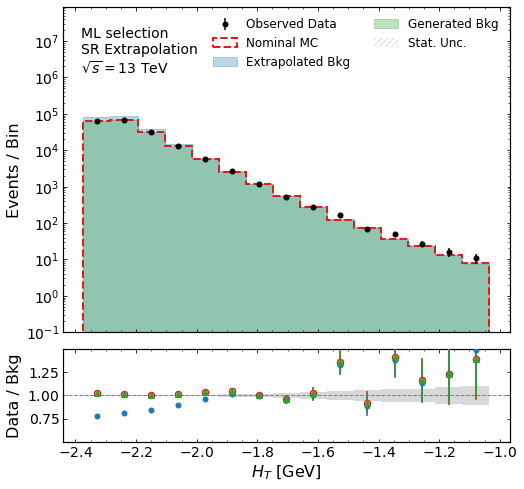

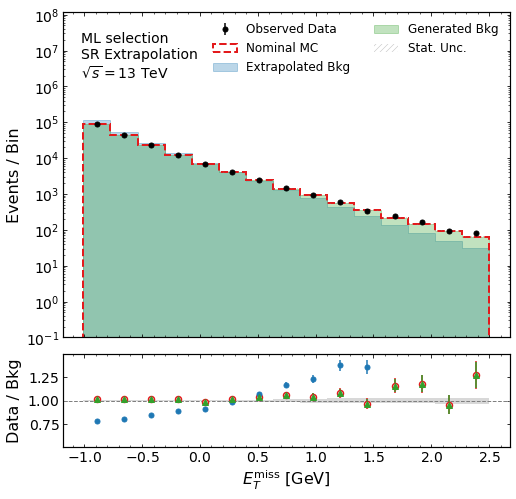

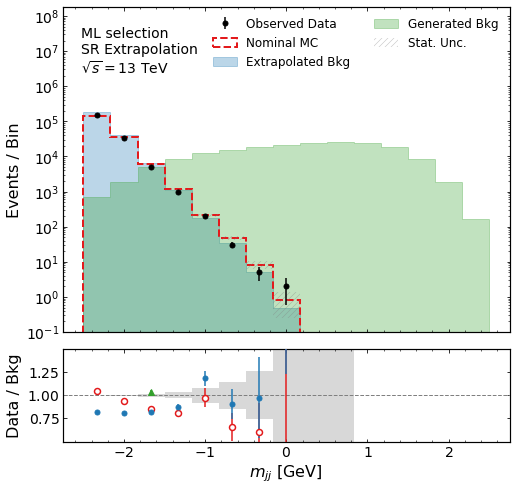

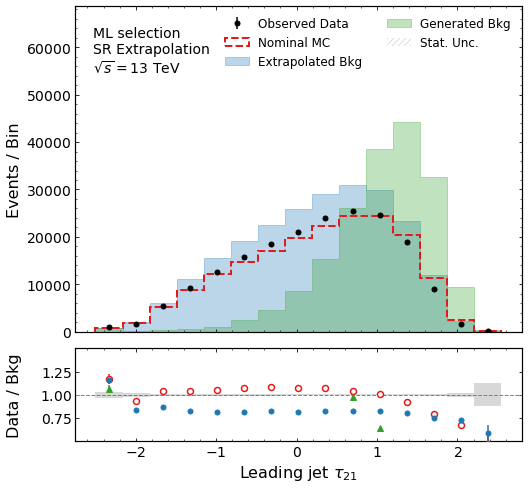

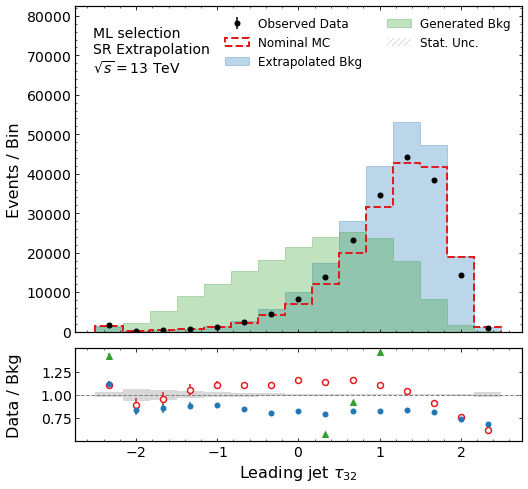

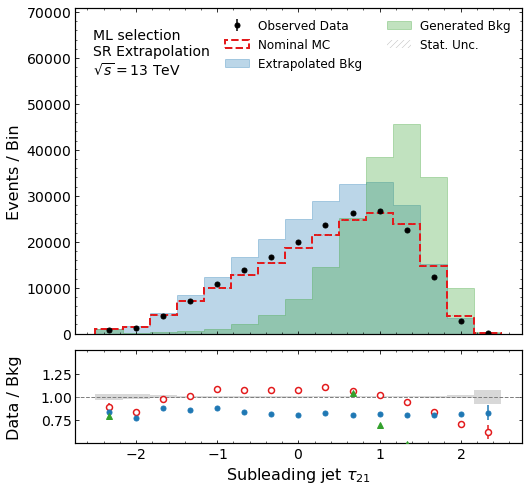

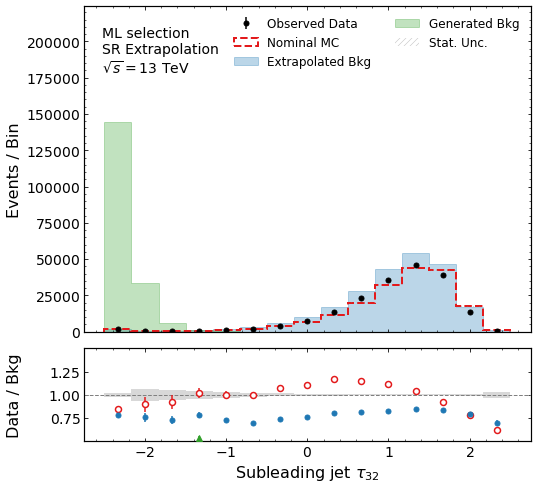


Converting to Pandas arrays for CWoLa training...

Data successfully formatted.
  X_mc shape: (528846, 5), w_mc_nom shape: (528846,)
  X_data shape: (188757, 5), w_data shape: (188757,)


In [5]:
selection = "ML" 

print(f"Loading SR events for {selection}...")
try:
    df_mc = pl.read_parquet(f"AD_Events/SR_events_mc_{selection}.parquet")
    df_data = pl.read_parquet(f"AD_Events/SR_events_data_{selection}.parquet")
    
    # Handle Generated Data gracefully (might not exist for SR yet)
    if os.path.exists(f"AD_Events/SR_events_gen_{selection}.parquet"):
        df_gen = pl.read_parquet(f"AD_Events/SR_events_gen_{selection}.parquet")
    else:
        print("Generated events file not found. Proceeding without df_gen.")
        df_gen = None
        
except Exception as e:
    print(f"Error loading files. Ensure the 'AD_Events' folder exists.\nError: {e}")
    sys.exit(1)

# Define Variables
context_var = ['ht', 'met_recalc_pt']
exclude_cols = context_var + ['final_weight', 'extrapolated_SR_weight', 'raw_weights', 'weight', 'label']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
all_variables_to_plot = context_var + features

# Generate Pre-CWoLa PDF Plots
print(f"\nGenerating SR Extrapolation Plots for {selection}...")
for var in all_variables_to_plot:
    try:
        plot_sr_extrapolation(mode_label=selection, df_mc=df_mc, df_gen=df_gen, df_data=df_data, feature=var, force_log=False)
    except Exception as e:
        print(f"  Failed to plot {var}: {e}")

# Prepare Data Arrays
print("\nConverting to Pandas arrays for CWoLa training...")
mc_events_sr = df_mc.to_pandas()
data_events_sr = df_data.to_pandas()

X_mc = mc_events_sr[features].values 
X_data = data_events_sr[features].values

# Extract SR Weights (Nominal vs Extrapolated)
w_mc_nominal = mc_events_sr['final_weight'].values if 'final_weight' in mc_events_sr.columns else np.ones(len(X_mc))
w_mc_extrap = mc_events_sr['extrapolated_SR_weight'].values if 'extrapolated_SR_weight' in mc_events_sr.columns else np.ones(len(X_mc))
w_data = data_events_sr['final_weight'].values if 'final_weight' in data_events_sr.columns else np.ones(len(X_data))

print("\nData successfully formatted.")
print(f"  X_mc shape: {X_mc.shape}, w_mc_nom shape: {w_mc_nominal.shape}")
print(f"  X_data shape: {X_data.shape}, w_data shape: {w_data.shape}")


In [6]:
# CWoLa Setup
device = "cpu"
config_path = "/home/aegis/Titan1/NRAD/data/configs"
eval_dir = f"Eval_CWoLa_SR_{selection}"
os.makedirs(eval_dir, exist_ok=True)

with open(f"{config_path}/bc_discrim.yml", 'r') as stream:
    params = yaml.safe_load(stream)

In [7]:

# 1. Target Data vs. Nominal MC
print("\n[SR] Starting CWoLa: Data vs Nominal MC")
run_eval(X_data, X_mc, code=f"Data_vs_Nom_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_mc_nominal)


[SR] Starting CWoLa: Data vs Nominal MC
      Regularizing weights (Mean: 1.0000, Std: 0.0000)
      Regularizing weights (Mean: 0.3506, Std: 0.4684)

Working on Data_vs_Nom_ML...
      Total Events - Set 1: 188757, Set 2: 528846

Classifier run 1 of 20.
      Train shapes: X:(574081, 5), y:(574081, 1), w:(574081, 1)
      Test shapes: X:(143522, 5), y:(143522, 1)
Using device: cpu


 38%|===>      | 19/50 [51:30<1:24:01, 162.64s/it]


   --> AUC: 0.5592

Classifier run 2 of 20.


 24%|==        | 12/50 [34:03<1:47:51, 170.31s/it]


   --> AUC: 0.5584

Classifier run 3 of 20.


...

   --> AUC: 0.5594

Classifier run 19 of 20.


 28%|==>       | 14/50 [38:26<1:38:51, 164.78s/it]


   --> AUC: 0.5581

Classifier run 20 of 20.


 16%|=>        | 8/50 [25:35<2:14:21, 191.93s/it]


   --> AUC: 0.5585

--- Summary for Data_vs_Nom_ML ---
Median AUC:       0.5585
16th percentile:  0.5565
84th percentile:  0.5593
Done.



In [8]:

# 2. Target Data vs. Extrapolated MC
print("\n[SR] Starting CWoLa: Data vs Extrapolated MC")
run_eval(X_data, X_mc, code=f"Data_vs_Extrap_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_mc_extrap)



[SR] Starting CWoLa: Data vs Extrapolated MC
      Regularizing weights (Mean: 1.0000, Std: 0.0000)
      Regularizing weights (Mean: 0.4361, Std: 0.6103)

Working on Data_vs_Extrap_ML...
      Total Events - Set 1: 188757, Set 2: 528846

Classifier run 1 of 20.
      Train shapes: X:(574081, 5), y:(574081, 1), w:(574081, 1)
      Test shapes: X:(143522, 5), y:(143522, 1)
Using device: cpu


 32%|===       | 16/50 [45:22<1:36:25, 170.15s/it]


   --> AUC: 0.5214

Classifier run 2 of 20.


 32%|===       | 16/50 [45:26<1:36:32, 170.38s/it]


   --> AUC: 0.5232

Classifier run 3 of 20.


...

   --> AUC: 0.5214

Classifier run 19 of 20.


 16%|=>        | 8/50 [23:16<2:02:09, 174.51s/it]


   --> AUC: 0.5191

Classifier run 20 of 20.


 24%|==        | 12/50 [33:19<1:45:30, 166.60s/it]


   --> AUC: 0.5196

--- Summary for Data_vs_Extrap_ML ---
Median AUC:       0.5214
16th percentile:  0.5197
84th percentile:  0.5229
Done.



In [9]:

# 3. Target Data vs. Generated Data (If exists)
if df_gen is not None:
    gen_events_sr = df_gen.to_pandas()
    X_gen = gen_events_sr[features].values
    w_gen = gen_events_sr['weight'].values if 'weight' in gen_events_sr.columns else np.ones(len(X_gen))
    
    print("\n[SR] Starting CWoLa: Data vs Generated")
    run_eval(X_data, X_gen, code=f"Data_vs_Gen_{selection}", save_dir=eval_dir, classifier_params=params, device=device, w_1=w_data, w_2=w_gen)


[SR] Starting CWoLa: Data vs Generated
      Regularizing weights (Mean: 1.0000, Std: 0.0000)
      Regularizing weights (Mean: 0.3506, Std: 0.4684)

Working on Data_vs_Gen_ML...
      Total Events - Set 1: 188757, Set 2: 528846

Classifier run 1 of 20.
      Train shapes: X:(574081, 5), y:(574081, 1), w:(574081, 1)
      Test shapes: X:(143522, 5), y:(143522, 1)
Using device: cpu


 36%|===>      | 18/50 [49:04<1:27:14, 163.57s/it]


   --> AUC: 1.0000

Classifier run 2 of 20.


 20%|==        | 10/50 [28:07<1:52:28, 168.71s/it]


   --> AUC: 1.0000

Classifier run 3 of 20.


...

   --> AUC: 1.0000

Classifier run 19 of 20.


 18%|=>        | 9/50 [26:31<2:00:49, 176.81s/it]


   --> AUC: 1.0000

Classifier run 20 of 20.


 46%|====>     | 23/50 [1:02:36<1:13:29, 163.31s/it]


   --> AUC: 1.0000

--- Summary for Data_vs_Gen_ML ---
Median AUC:       1.0000
16th percentile:  1.0000
84th percentile:  1.0000
Done.

